In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
data = pd.read_csv('American_Housing_Data_20231209.xls')
data

,Zip Code,Price,Beds,Baths,Living Space,Address,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,74 GRAND ST APT 3,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,140 CHARLES ST APT 4D,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,38 JONES ST,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,81 BEDFORD ST APT 3F,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,2495000.0,4,4,3380,2626 27TH AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,3215 32ND AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,3257 22ND AVE W,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,3711 26TH PL W APT 102,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223


In [23]:
data.dtypes

Zip Code                     int64
Price                      float64
Beds                         int64
Baths                        int64
Living Space                 int64
Address                        str
City                           str
State                          str
Zip Code Population          int64
Zip Code Density           float64
County                         str
Median Household Income    float64
Latitude                   float64
Longitude                  float64
dtype: object

In [24]:
data.columns

Index(['Zip Code', 'Price', 'Beds', 'Baths', 'Living Space', 'Address', 'City',
       'State', 'Zip Code Population', 'Zip Code Density', 'County',
       'Median Household Income', 'Latitude', 'Longitude'],
      dtype='str')

In [25]:
data.drop('Address',axis=1,inplace=True)
data

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,New York,New York,29563,20967.9,New York,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,New York,New York,29815,23740.9,New York,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,2495000.0,4,4,3380,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,Seattle,Washington,22890,2086.8,King,205611.0,47.65139,-122.40223


In [26]:
le_City = LabelEncoder()
data['City'] = le_City.fit_transform(data['City'])

le_State = LabelEncoder()
data['State'] = le_State.fit_transform(data['State'])

le_County = LabelEncoder()
data['County'] = le_County.fit_transform(data['County'])

data

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
0,10013,3999000.0,2,3,1967,150,18,29563,20967.9,57,370046.0,40.72001,-74.00472
1,10013,3999000.0,2,3,1967,150,18,29563,20967.9,57,370046.0,40.72001,-74.00472
2,10014,1650000.0,1,1,718,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
3,10014,760000.0,3,2,1538,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
4,10014,1100000.0,1,1,600,150,18,29815,23740.9,57,249880.0,40.73407,-74.00601
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39976,98199,2495000.0,4,4,3380,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39977,98199,2295000.0,4,4,2878,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39978,98199,950000.0,3,2,1380,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223
39979,98199,425000.0,2,1,856,204,27,22890,2086.8,46,205611.0,47.65139,-122.40223


In [27]:
data.dtypes

Zip Code                     int64
Price                      float64
Beds                         int64
Baths                        int64
Living Space                 int64
City                         int64
State                        int64
Zip Code Population          int64
Zip Code Density           float64
County                       int64
Median Household Income    float64
Latitude                   float64
Longitude                  float64
dtype: object

In [28]:
data.isnull().sum()

Zip Code                   0
Price                      0
Beds                       0
Baths                      0
Living Space               0
City                       0
State                      0
Zip Code Population        0
Zip Code Density           0
County                     0
Median Household Income    2
Latitude                   0
Longitude                  0
dtype: int64

In [29]:
data = data.dropna()

In [30]:
data.isnull().sum()

Zip Code                   0
Price                      0
Beds                       0
Baths                      0
Living Space               0
City                       0
State                      0
Zip Code Population        0
Zip Code Density           0
County                     0
Median Household Income    0
Latitude                   0
Longitude                  0
dtype: int64

In [31]:
# df=df.drop_duplicates()

{'whiskers': [<matplotlib.lines.Line2D at 0x21819cc4b90>,
 'caps': [<matplotlib.lines.Line2D at 0x21819cc4650>,
 'boxes': [<matplotlib.patches.PathPatch at 0x21819cc4ef0>],
 'medians': [<matplotlib.lines.Line2D at 0x21819cc4110>],
 'fliers': [<matplotlib.lines.Line2D at 0x21819f13f80>],
 'means': []}

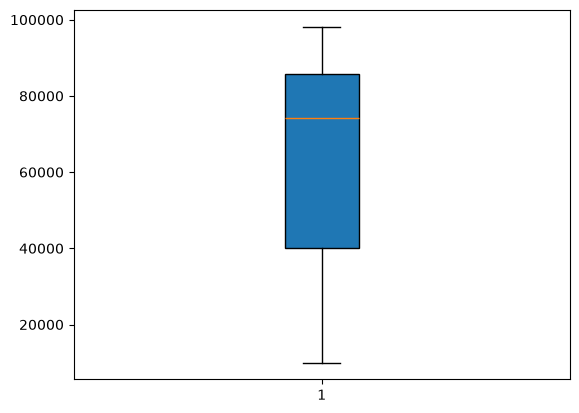

In [32]:
plt.boxplot(data['Zip Code'],patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x21819e7afc0>,
 'caps': [<matplotlib.lines.Line2D at 0x21819e9daf0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x21819cc5010>],
 'medians': [<matplotlib.lines.Line2D at 0x21819e9d730>],
 'fliers': [<matplotlib.lines.Line2D at 0x21819e9d4f0>],
 'means': []}

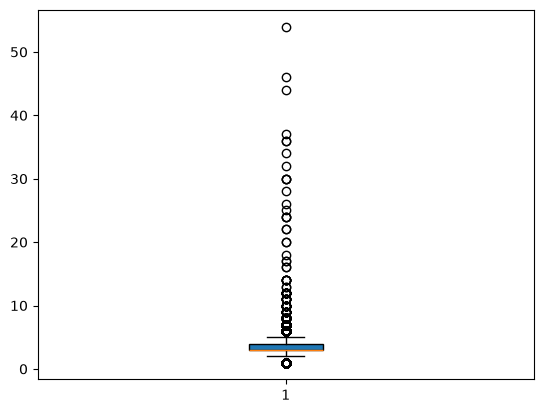

In [33]:
plt.boxplot(data['Beds'],patch_artist=True)

In [34]:
q1 = data.Beds.quantile(0.25)
q3 = data.Beds.quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Beds'] >= upper)[0]
lower_index = np.where(data['Beds'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

{'whiskers': [<matplotlib.lines.Line2D at 0x217d67c4fb0>,
 'caps': [<matplotlib.lines.Line2D at 0x217d67c5490>,
 'boxes': [<matplotlib.patches.PathPatch at 0x217d67c4d10>],
 'medians': [<matplotlib.lines.Line2D at 0x217d67c59d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x217d67c5c40>],
 'means': []}

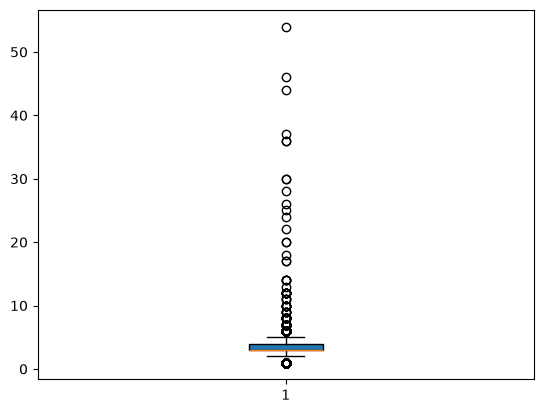

In [35]:
plt.boxplot(data['Beds'],patch_artist=True)

In [36]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

In [37]:
q1 = data.Beds.quantile(0.25)
q3 = data.Beds.quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Beds'] >= upper)[0]
lower_index = np.where(data['Beds'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

{'whiskers': [<matplotlib.lines.Line2D at 0x21819c501a0>,
 'caps': [<matplotlib.lines.Line2D at 0x21819c3fc20>,
 'boxes': [<matplotlib.patches.PathPatch at 0x21819c503e0>],
 'medians': [<matplotlib.lines.Line2D at 0x21819c3f830>],
 'fliers': [<matplotlib.lines.Line2D at 0x21819c3f5f0>],
 'means': []}

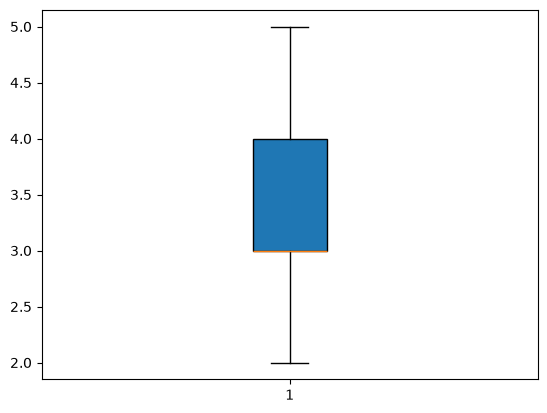

In [38]:
plt.boxplot(data['Beds'], patch_artist=True)

In [39]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x21819d13cb0>,
 'caps': [<matplotlib.lines.Line2D at 0x21819d137a0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x21819d13ef0>],
 'medians': [<matplotlib.lines.Line2D at 0x21819d13290>],
 'fliers': [<matplotlib.lines.Line2D at 0x21819d13050>],
 'means': []}

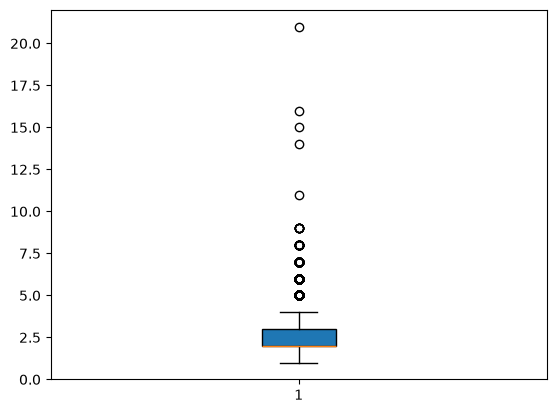

In [40]:
plt.boxplot(data['Baths'], patch_artist=True)

In [41]:
q1 = data.Baths.quantile(0.25)
q3 = data.Baths.quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Baths'] >= upper)[0]
lower_index = np.where(data['Baths'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

{'whiskers': [<matplotlib.lines.Line2D at 0x21819d24830>,
 'caps': [<matplotlib.lines.Line2D at 0x21819d5d940>,
 'boxes': [<matplotlib.patches.PathPatch at 0x21819d5dfd0>],
 'medians': [<matplotlib.lines.Line2D at 0x21819d5d430>],
 'fliers': [<matplotlib.lines.Line2D at 0x21819d5d1c0>],
 'means': []}

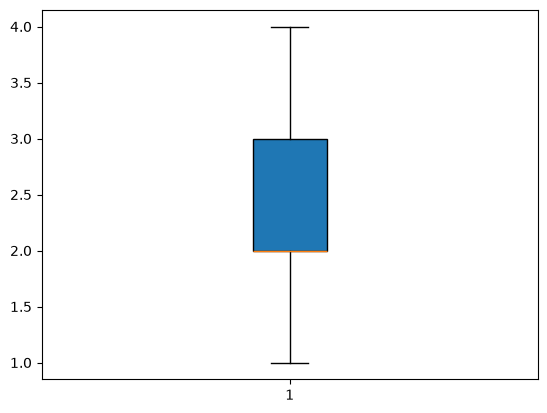

In [42]:
plt.boxplot(data['Baths'], patch_artist = True)

In [43]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x21819f37440>,
 'caps': [<matplotlib.lines.Line2D at 0x21819f36240>,
 'boxes': [<matplotlib.patches.PathPatch at 0x21819f366f0>],
 'medians': [<matplotlib.lines.Line2D at 0x21819f35d30>],
 'fliers': [<matplotlib.lines.Line2D at 0x21819f35ac0>],
 'means': []}

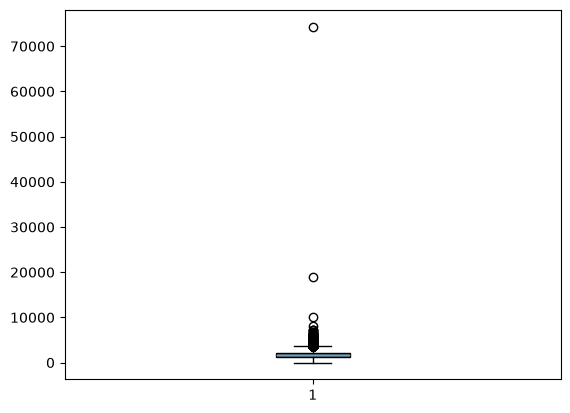

In [44]:
plt.boxplot(data['Living Space'], patch_artist=True)

In [45]:
q1 = data['Living Space'].quantile(0.25)
q3 = data['Living Space'].quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Living Space'] >= upper)[0]
lower_index = np.where(data['Living Space'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

{'whiskers': [<matplotlib.lines.Line2D at 0x21819f2cd40>,
 'caps': [<matplotlib.lines.Line2D at 0x21819f00f50>,
 'boxes': [<matplotlib.patches.PathPatch at 0x21819f01700>],
 'medians': [<matplotlib.lines.Line2D at 0x21819f00a40>],
 'fliers': [<matplotlib.lines.Line2D at 0x21819f007a0>],
 'means': []}

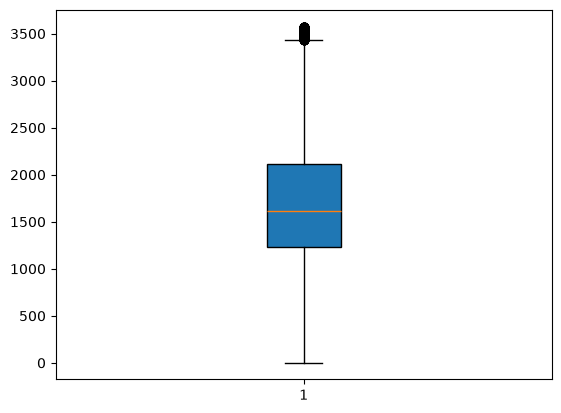

In [46]:
plt.boxplot(data['Living Space'], patch_artist=True)

In [47]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

In [48]:
data.columns

Index(['Zip Code', 'Price', 'Beds', 'Baths', 'Living Space', 'City', 'State',
       'Zip Code Population', 'Zip Code Density', 'County',
       'Median Household Income', 'Latitude', 'Longitude'],
      dtype='str')

{'whiskers': [<matplotlib.lines.Line2D at 0x217d67f4260>,
 'caps': [<matplotlib.lines.Line2D at 0x217d67ebec0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x217d67f4470>],
 'medians': [<matplotlib.lines.Line2D at 0x217d67eb980>],
 'fliers': [<matplotlib.lines.Line2D at 0x217d67eb710>],
 'means': []}

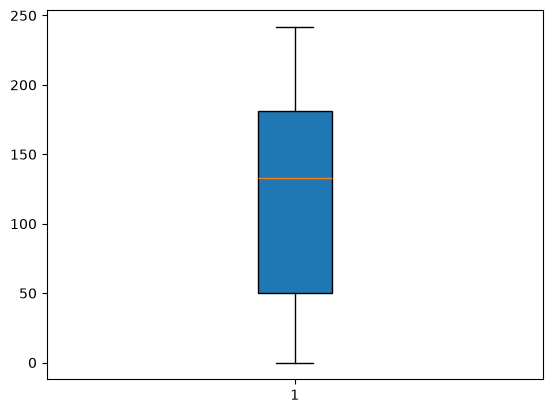

In [49]:
plt.boxplot(data['City'], patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x217d6617140>,
 'caps': [<matplotlib.lines.Line2D at 0x217d6617650>,
 'boxes': [<matplotlib.patches.PathPatch at 0x217d66fcf50>],
 'medians': [<matplotlib.lines.Line2D at 0x217d6617b90>],
 'fliers': [<matplotlib.lines.Line2D at 0x217d6617e30>],
 'means': []}

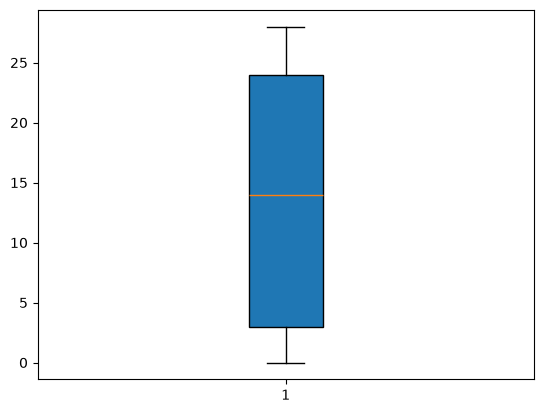

In [50]:
plt.boxplot(data['State'], patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x217d67d5c10>,
 'caps': [<matplotlib.lines.Line2D at 0x217d67d6180>,
 'boxes': [<matplotlib.patches.PathPatch at 0x217d683cf50>],
 'medians': [<matplotlib.lines.Line2D at 0x217d67d66c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x217d67d6930>],
 'means': []}

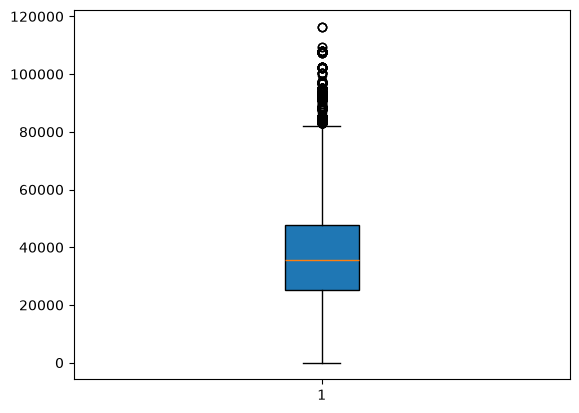

In [51]:
plt.boxplot(data['Zip Code Population'], patch_artist=True)

In [52]:
q1 = data['Zip Code Population'].quantile(0.25)
q3 = data['Zip Code Population'].quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Zip Code Population'] >= upper)[0]
lower_index = np.where(data['Zip Code Population'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

{'whiskers': [<matplotlib.lines.Line2D at 0x21819ea1430>,
 'caps': [<matplotlib.lines.Line2D at 0x21819ea08f0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x21819f5b8f0>],
 'medians': [<matplotlib.lines.Line2D at 0x21819ef1f10>],
 'fliers': [<matplotlib.lines.Line2D at 0x21819ef35f0>],
 'means': []}

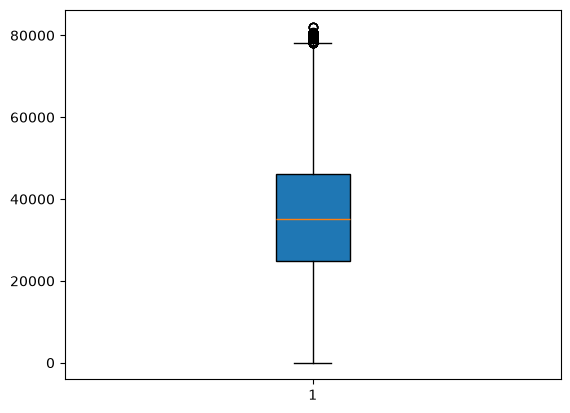

In [53]:
plt.boxplot(data['Zip Code Population'], patch_artist=True)

In [54]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x217d69308c0>,
 'caps': [<matplotlib.lines.Line2D at 0x217d6193da0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x217d6930950>],
 'medians': [<matplotlib.lines.Line2D at 0x217d6191af0>],
 'fliers': [<matplotlib.lines.Line2D at 0x217d402bf50>],
 'means': []}

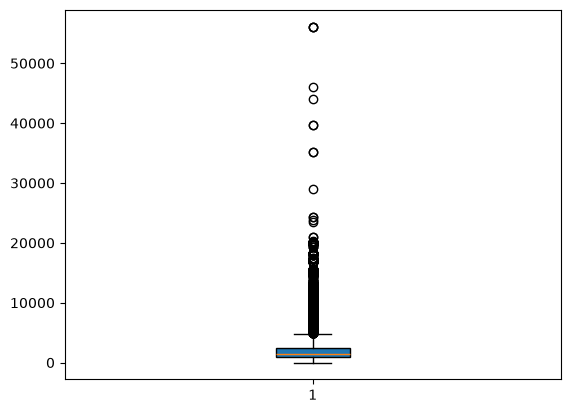

In [55]:
plt.boxplot(data['Zip Code Density'], patch_artist=True)

In [56]:
q1 = data['Zip Code Density'].quantile(0.25)
q3 = data['Zip Code Density'].quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Zip Code Density'] >= upper)[0]
lower_index = np.where(data['Zip Code Density'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

{'whiskers': [<matplotlib.lines.Line2D at 0x217d678c830>,
 'caps': [<matplotlib.lines.Line2D at 0x217d6772330>,
 'boxes': [<matplotlib.patches.PathPatch at 0x217d67e7980>],
 'medians': [<matplotlib.lines.Line2D at 0x217d6770aa0>],
 'fliers': [<matplotlib.lines.Line2D at 0x217d67581d0>],
 'means': []}

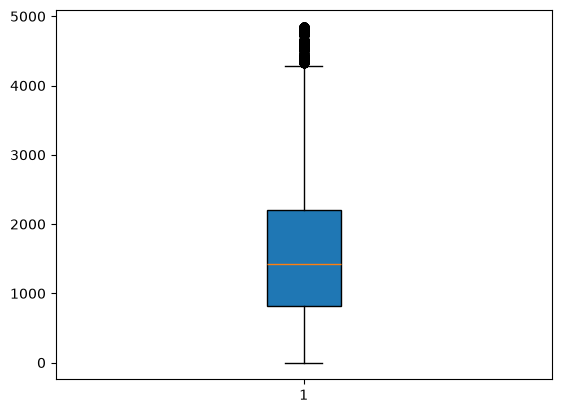

In [57]:
plt.boxplot(data['Zip Code Density'], patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x217d6744830>,
 'caps': [<matplotlib.lines.Line2D at 0x217d6732fc0>,
 'boxes': [<matplotlib.patches.PathPatch at 0x217d6732b40>],
 'medians': [<matplotlib.lines.Line2D at 0x217d67334d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x217d67335f0>],
 'means': []}

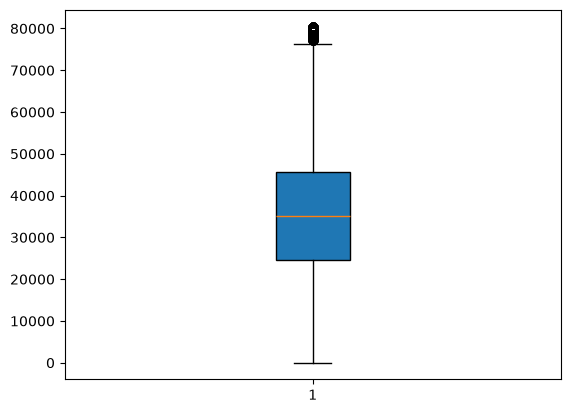

In [58]:
plt.boxplot(data['Zip Code Population'], patch_artist=True)


{'whiskers': [<matplotlib.lines.Line2D at 0x217d68e1220>,
 'caps': [<matplotlib.lines.Line2D at 0x217d68e1460>,
 'boxes': [<matplotlib.patches.PathPatch at 0x217d614cf50>],
 'medians': [<matplotlib.lines.Line2D at 0x217d68e1880>],
 'fliers': [<matplotlib.lines.Line2D at 0x217d68e0d10>],
 'means': []}

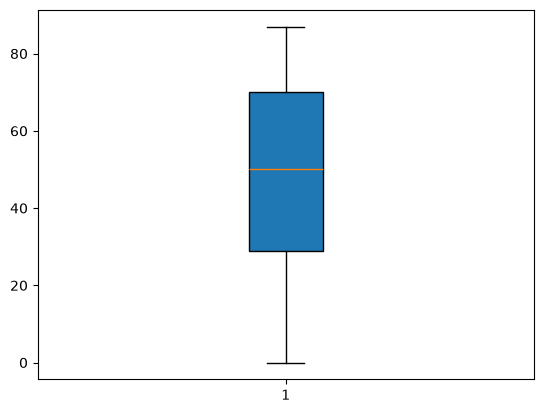

In [59]:
plt.boxplot(data['County'], patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x21819e6cfb0>,
 'caps': [<matplotlib.lines.Line2D at 0x21819e6d460>,
 'boxes': [<matplotlib.patches.PathPatch at 0x21819e6cc50>],
 'medians': [<matplotlib.lines.Line2D at 0x21819e6d9a0>],
 'fliers': [<matplotlib.lines.Line2D at 0x21819e6dc40>],
 'means': []}

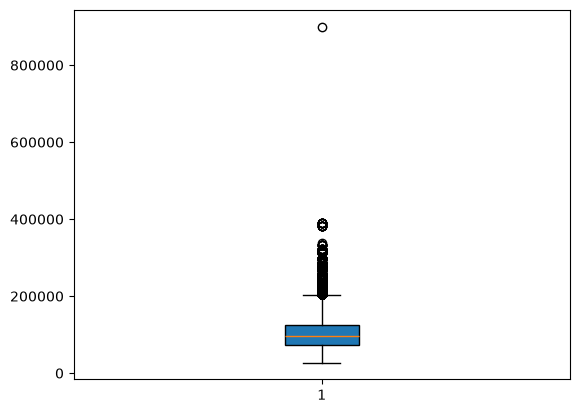

In [60]:
plt.boxplot(data['Median Household Income'], patch_artist=True)

In [61]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

In [62]:
q1 = data['Median Household Income'].quantile(0.25)
q3 = data['Median Household Income'].quantile(0.75)
IQR = q3-q1

lower= q1 - 1.5 * IQR
upper= q3 + 1.5 * IQR

upper_index = np.where(data['Median Household Income'] >= upper)[0]
lower_index = np.where(data['Median Household Income'] <= lower)[0]

data.drop(index = upper_index, inplace = True)
data.drop(index = lower_index, inplace = True)

{'whiskers': [<matplotlib.lines.Line2D at 0x217d695b530>,
 'caps': [<matplotlib.lines.Line2D at 0x217d68b9730>,
 'boxes': [<matplotlib.patches.PathPatch at 0x217d695a2d0>],
 'medians': [<matplotlib.lines.Line2D at 0x217d68ba690>],
 'fliers': [<matplotlib.lines.Line2D at 0x217d68ba870>],
 'means': []}

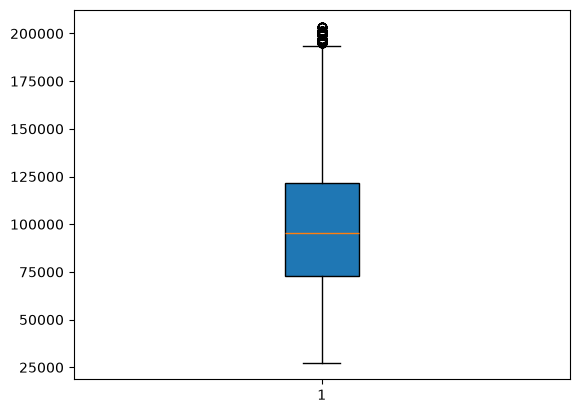

In [63]:
plt.boxplot(data['Median Household Income'], patch_artist=True)

In [64]:
data.reset_index(inplace=True)
data.drop('index', axis=1, inplace=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x2181a022fc0>,
 'caps': [<matplotlib.lines.Line2D at 0x2181a04a210>,
 'boxes': [<matplotlib.patches.PathPatch at 0x2181a0329c0>],
 'medians': [<matplotlib.lines.Line2D at 0x2181a04a6c0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2181a04a900>],
 'means': []}

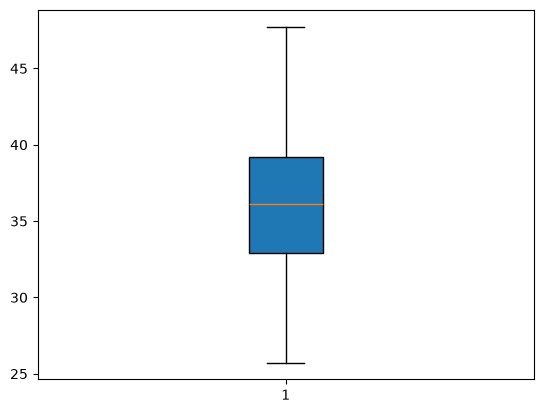

In [65]:
plt.boxplot(data['Latitude'], patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x2181b19b8c0>,
 'caps': [<matplotlib.lines.Line2D at 0x2181b19be00>,
 'boxes': [<matplotlib.patches.PathPatch at 0x2181b19b680>],
 'medians': [<matplotlib.lines.Line2D at 0x2181b1c4350>],
 'fliers': [<matplotlib.lines.Line2D at 0x2181b1c45f0>],
 'means': []}

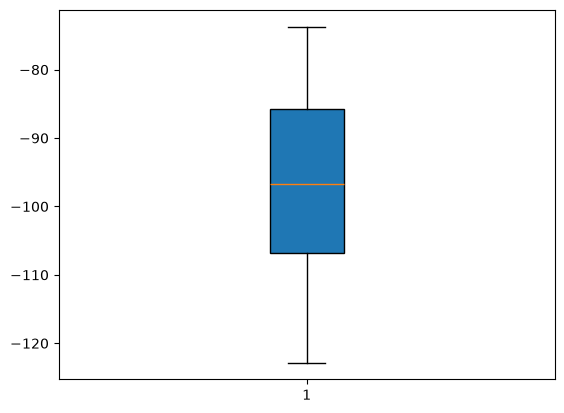

In [66]:
plt.boxplot(data['Longitude'], patch_artist=True)

{'whiskers': [<matplotlib.lines.Line2D at 0x2181b1f9d00>,
 'caps': [<matplotlib.lines.Line2D at 0x2181b1fa120>,
 'boxes': [<matplotlib.patches.PathPatch at 0x2181b1e29c0>],
 'medians': [<matplotlib.lines.Line2D at 0x2181b1fa660>],
 'fliers': [<matplotlib.lines.Line2D at 0x2181b1fa900>],
 'means': []}

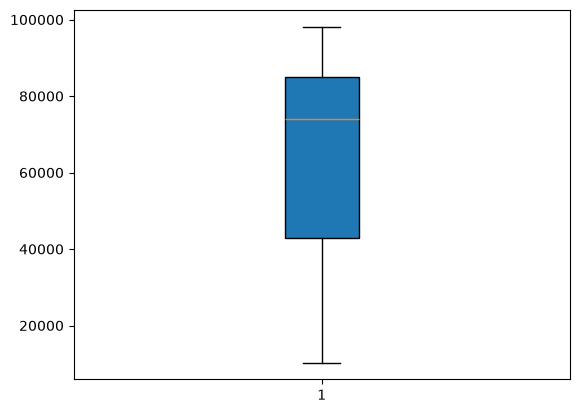

In [67]:
plt.boxplot(data['Zip Code'], patch_artist=True)

In [68]:
correlation = data.corr()
correlation

,Zip Code,Price,Beds,Baths,Living Space,City,State,Zip Code Population,Zip Code Density,County,Median Household Income,Latitude,Longitude
Zip Code,1.000000,0.209820,0.008705,-0.017887,0.042700,0.089928,-0.193085,-0.039483,0.059938,-0.070388,0.159754,-0.057707,-0.935443
Price,0.209820,1.000000,0.185014,0.379914,0.405616,0.117895,-0.195045,-0.004050,0.237476,0.014871,0.520516,-0.084566,-0.298316
Beds,0.008705,0.185014,1.000000,0.452910,0.617816,-0.015620,0.067391,0.078877,-0.137967,0.006676,0.049810,-0.043278,0.018104
Baths,-0.017887,0.379914,0.452910,1.000000,0.686776,-0.018199,0.055365,0.063842,-0.112010,-0.046370,0.293977,-0.124017,0.017631
Living Space,0.042700,0.405616,0.617816,0.686776,1.000000,-0.010626,0.068914,0.001976,-0.176110,-0.024321,0.285499,-0.080529,-0.013659
City,0.089928,0.117895,-0.015620,-0.018199,-0.010626,1.000000,-0.086521,-0.040357,0.038847,0.309544,0.104387,0.093009,-0.171297
State,-0.193085,-0.195045,0.067391,0.055365,0.068914,-0.086521,1.000000,0.078992,-0.135489,0.088170,-0.072370,0.022891,0.325374
Zip Code Population,-0.039483,-0.004050,0.078877,0.063842,0.001976,-0.040357,0.078992,1.000000,0.071873,-0.051409,-0.027933,-0.113662,-0.002877
Zip Code Density,0.059938,0.237476,-0.137967,-0.112010,-0.176110,0.038847,-0.135489,0.071873,1.000000,-0.043425,0.021964,0.233971,-0.108685
County,-0.070388,0.014871,0.006676,-0.046370,-0.024321,0.309544,0.088170,-0.051409,-0.043425,1.000000,0.018429,0.010245,0.080487


<Axes: >

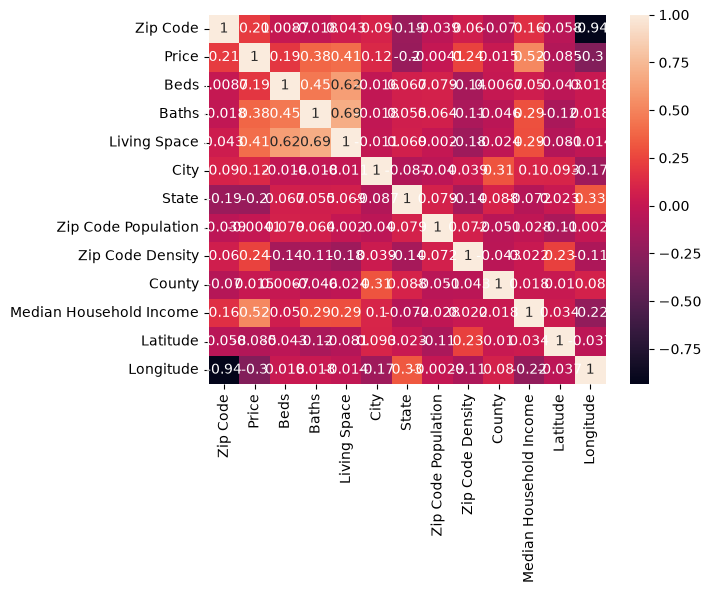

In [69]:
sns.heatmap(correlation, annot=True)

In [70]:
data.drop('Zip Code Population', axis=1, inplace=True)

In [71]:
data.drop('County', axis=1, inplace=True)

In [72]:
data.drop('Latitude', axis=1, inplace=True)

In [73]:
data.drop('Zip Code', axis=1, inplace=True)

In [74]:
correlation = data.corr()
correlation

,Price,Beds,Baths,Living Space,City,State,Zip Code Density,Median Household Income,Longitude
Price,1.000000,0.185014,0.379914,0.405616,0.117895,-0.195045,0.237476,0.520516,-0.298316
Beds,0.185014,1.000000,0.452910,0.617816,-0.015620,0.067391,-0.137967,0.049810,0.018104
Baths,0.379914,0.452910,1.000000,0.686776,-0.018199,0.055365,-0.112010,0.293977,0.017631
Living Space,0.405616,0.617816,0.686776,1.000000,-0.010626,0.068914,-0.176110,0.285499,-0.013659
City,0.117895,-0.015620,-0.018199,-0.010626,1.000000,-0.086521,0.038847,0.104387,-0.171297
State,-0.195045,0.067391,0.055365,0.068914,-0.086521,1.000000,-0.135489,-0.072370,0.325374
Zip Code Density,0.237476,-0.137967,-0.112010,-0.176110,0.038847,-0.135489,1.000000,0.021964,-0.108685
Median Household Income,0.520516,0.049810,0.293977,0.285499,0.104387,-0.072370,0.021964,1.000000,-0.224919
Longitude,-0.298316,0.018104,0.017631,-0.013659,-0.171297,0.325374,-0.108685,-0.224919,1.000000


<Axes: >

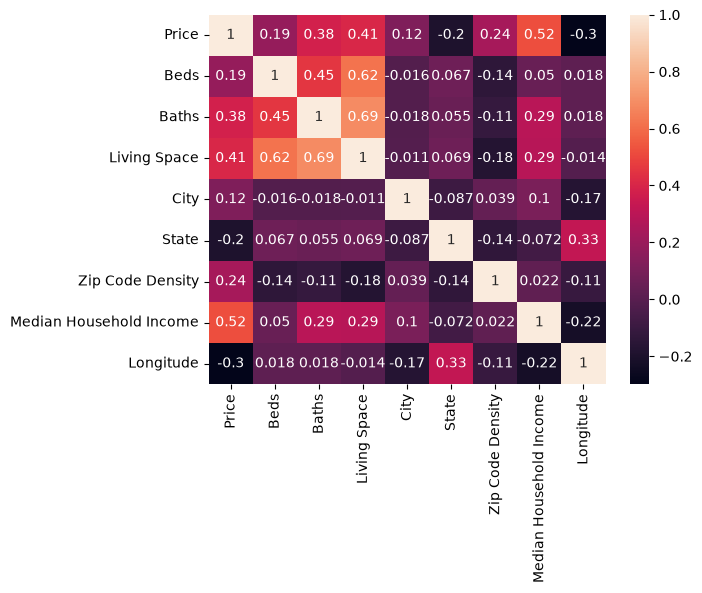

In [75]:
sns.heatmap(correlation, annot=True)

In [76]:
x = data.drop('Price', axis=1)
y = data['Price']

In [77]:
# x=df[['Beds','Baths','Living Space']]
# y=df['Price']

In [78]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=20)

In [79]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-5672.8 ,57939.42, 149.82,..., 84.74, 3.6 ,-3699.94]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Beds','Baths','Living Space',...,'Zip Code Density', 'Median Household Income','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-7.596e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [80]:
model.score(x_test,y_test)

0.4562753841347116

In [81]:
model.score(x_train,y_train)

0.4787577178564896

In [82]:
y_pred=model.predict(x_test)

In [83]:
pd.DataFrame({'True values': y_test, 'Predicted values': y_pred})

,True values,Predicted values
7350,539900.0,431025.647230
28876,550000.0,284422.133293
23451,495000.0,695530.997240
28903,791000.0,861779.659778
15796,349950.0,384005.432518
...,...,...
12197,119900.0,118359.276066
11811,150000.0,62712.960776
19775,179950.0,289904.641500
25704,968800.0,662545.986839


In [84]:
mean_absolute_error(y_test,y_pred)

153327.85411612762

In [85]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:",mse)
print("R2:",r2)

MSE: 72130236677.98265
R2: 0.4562753841347116


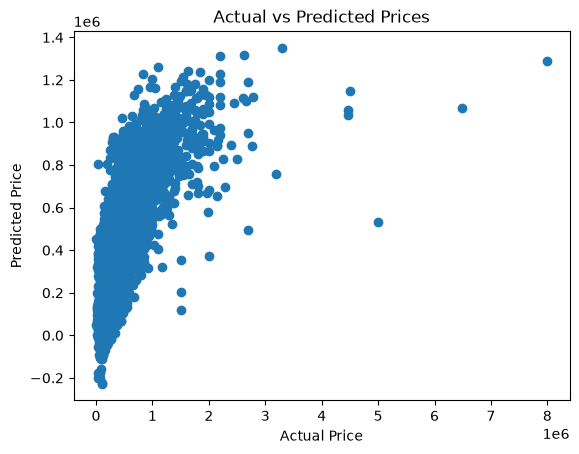

In [86]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [87]:
# import joblib

In [88]:
# joblib.dump(model, 'housing_model.pkl')

In [89]:
data.columns

Index(['Price', 'Beds', 'Baths', 'Living Space', 'City', 'State',
       'Zip Code Density', 'Median Household Income', 'Longitude'],
      dtype='str')

In [91]:
city_mapping = dict(zip(le_City.classes_, range(len(le_City.classes_))))
state_mapping = dict(zip(le_State.classes_, range(len(le_State.classes_))))

print("CITY MAP:")
print(city_mapping)

print("\nSTATE MAP:")
print(state_mapping)

print("\nSTATE-CITY:")
print(data[['State','City']].drop_duplicates().groupby('State')['City'].apply(list).to_dict())

CITY MAP:
{'Albuquerque': 0, 'Aledo': 1, 'Apache Junction': 2, 'Arlington': 3, 'Arverne': 4, 'Astoria': 5, 'Atascosa': 6, 'Atlanta': 7, 'Atlantic Beach': 8, 'Austin': 9, 'Baltimore': 10, 'Bayside': 11, 'Bellerose': 12, 'Bellevue': 13, 'Bennington': 14, 'Berkeley': 15, 'Beverly Hills': 16, 'Blacklick': 17, 'Boerne': 18, 'Broken Arrow': 19, 'Bronx': 20, 'Brooklyn': 21, 'Brownsburg': 22, 'Burbank': 23, 'Burleson': 24, 'Calhan': 25, 'Cambria Heights': 26, 'Campbell': 27, 'Canal Winchester': 28, 'Canoga Park': 29, 'Catonsville': 30, 'Cave Creek': 31, 'Charlotte': 32, 'Chatsworth': 33, 'Chesapeake': 34, 'Chicago': 35, 'Choctaw': 36, 'Clint': 37, 'College Point': 38, 'Colorado Springs': 39, 'Columbus': 40, 'Converse': 41, 'Cordova': 42, 'Corona': 43, 'Crowley': 44, 'Culver City': 45, 'Curtis Bay': 46, 'Dallas': 47, 'Del Mar': 48, 'Denver': 49, 'Detroit': 50, 'Dublin': 51, 'Dundalk': 52, 'Durham': 53, 'East Elmhurst': 54, 'Edmond': 55, 'El Paso': 56, 'Elkhorn': 57, 'Elmhurst': 58, 'Elmwood Par

In [93]:
city_mapping = dict(zip(le_City.classes_, range(len(le_City.classes_))))
state_mapping = dict(zip(le_State.classes_, range(len(le_State.classes_))))
state_city_mapping = (
    data[['State', 'City']]
    .drop_duplicates()
    .groupby('State')['City']
    .apply(list)
    .to_dict()
)

with open("mappings.py", "w", encoding="utf-8") as f:
    f.write("city_map = ")
    f.write(repr(city_mapping))
    f.write("\n\n")

    f.write("state_map = ")
    f.write(repr(state_mapping))
    f.write("\n\n")

    f.write("state_city_map = ")
    f.write(repr(state_city_mapping))